# **Modelos LSTM — Total mensual de viajeros**

En este notebook se trabaja la serie del **total mensual de viajeros**. La idea es probar modelos LSTM con distintas configuraciones, tunear algunos hiperparámetros y después quedarnos con la opción que tenga mejor desempeño.



## **Conjuntos de entrenamiento y prueba**

Para comparar los resultados con los modelos del Laboratorio 1, se usan los mismos archivos de entrenamiento y prueba: entrenamiento.csv y prueba.csv. 

El entrenamiento va de enero de 2009 a marzo de 2021, con 147 meses. La prueba va de abril de 2021 a junio de 2026, con 63 meses. La partición se mantiene en orden cronológico, porque en series de tiempo no conviene mezclar observaciones pasadas y futuras.

En este caso, la serie total mensual se reconstruye sumando los viajeros de cada mes y aplicando la misma transformación logarítmica usada en el laboratorio anterior. Luego, para calcular MAE y RMSE, se regresa a la escala original de viajeros usando la exponencial. Esto permite comparar los errores contra los modelos anteriores en las mismas unidades.


In [1]:
import os
import sys
import warnings
from pathlib import Path

Path("/private/tmp/matplotlib-cache").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "lstm" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import config
import utils

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 5)

SERIE = "total"
PERIODO = config.PERIODO

serie_train = utils.construir_serie(SERIE, "train")
serie_prueba = utils.construir_serie(SERIE, "prueba")

serie_train_log = np.log(serie_train)
serie_prueba_log = np.log(serie_prueba)

print("Serie:", config.SERIES_LAB1[SERIE]["etiqueta"])
print(f"Entrenamiento: {serie_train.index.min():%Y-%m} a {serie_train.index.max():%Y-%m}  "
      f"({len(serie_train)} meses)")
print(f"Prueba       : {serie_prueba.index.min():%Y-%m} a {serie_prueba.index.max():%Y-%m}  "
      f"({len(serie_prueba)} meses)")
print("Frecuencia   :", serie_train.index.freqstr, "(mensual, inicio de mes)")
print("Meses sin registro:", int(serie_train.isna().sum() + serie_prueba.isna().sum()))
print()
print("Mejor modelo para esta serie:")
print(f"  {config.MEJORES_LAB1[SERIE]['modelo']}  "
      f"MAE={config.MEJORES_LAB1[SERIE]['MAE']:,.0f}  "
      f"RMSE={config.MEJORES_LAB1[SERIE]['RMSE']:,.0f}")

serie_train.tail()

Serie: Total mensual
Entrenamiento: 2009-01 a 2021-03  (147 meses)
Prueba       : 2021-04 a 2026-06  (63 meses)
Frecuencia   : MS (mensual, inicio de mes)
Meses sin registro: 0

Mejor modelo para esta serie:
  Suav. exp. simple  MAE=158,777  RMSE=173,709


Fecha
2020-11-01    52865.000000
2020-12-01    55620.000000
2021-01-01    89960.000000
2021-02-01    52605.000000
2021-03-01    85017.396333
Freq: MS, Name: Viajero, dtype: float64

## **Diseño del tuneo de hiperparámetros**

Primero se comparan dos tipos de modelos LSTM:

1. **LSTM simple**: tiene una sola capa LSTM. Se usa como punto de comparación porque es un modelo más sencillo y debería tener menor riesgo de sobreajuste.
2. **LSTM apilada**: tiene dos capas LSTM y usa dropout. Esta tiene más capacidad para aprender patrones más complejos, pero también puede sobreajustarse más fácil, por eso se regulariza.

Los hiperparámetros que se tunean son:

- ventana: se prueban 12 y 24 meses. Con 12 meses el modelo ve un ciclo anual completo; con 24 meses puede usar dos ciclos anuales.
- unidades: se prueban 16 y 32 unidades. No se usan redes muy grandes porque la serie mensual no tiene demasiadas observaciones.
- dropout: se prueba solo en la LSTM apilada, ya que ahí hay más riesgo de sobreajuste.
- tasa_aprendizaje: se prueban 0.001 y 0.005 para ver qué tan rápido conviene que aprenda Adam.

Se dejan fijos batch_size = 16, epochs = 250 y early stopping. El early stopping ayuda a que el entrenamiento se detenga cuando el modelo ya no mejora, en lugar de forzar todas las épocas.

Para escoger la mejor configuración se usa validación de origen rodante. Esto significa que el modelo siempre entrena con meses anteriores y valida con los meses siguientes, respetando el orden de la serie. 


In [6]:
grilla_dos_modelos = []

for ventana in (12, 24):
    for tasa_aprendizaje in (0.001, 0.005):
        for unidades in (16, 32):
            grilla_dos_modelos.append({
                "familia": "A_simple",
                "ventana": ventana,
                "unidades": unidades,
                "capas": 1,
                "dropout": 0.0,
                "tasa_aprendizaje": tasa_aprendizaje,
                "epocas": 250,
                "paciencia": 30,
                "lote": 16,
            })

        for dropout in (0.1, 0.2):
            grilla_dos_modelos.append({
                "familia": "B_apilada_dropout",
                "ventana": ventana,
                "unidades": 32,
                "capas": 2,
                "dropout": dropout,
                "tasa_aprendizaje": tasa_aprendizaje,
                "epocas": 250,
                "paciencia": 30,
                "lote": 16,
            })

tabla_grilla = pd.DataFrame(grilla_dos_modelos)
print(f"Configuraciones a evaluar: {len(tabla_grilla)}")
tabla_grilla

Configuraciones a evaluar: 16


,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,epocas,paciencia,lote
0,A_simple,12,16,1,0.0,0.001,250,30,16
1,A_simple,12,32,1,0.0,0.001,250,30,16
2,B_apilada_dropout,12,32,2,0.1,0.001,250,30,16
3,B_apilada_dropout,12,32,2,0.2,0.001,250,30,16
4,A_simple,12,16,1,0.0,0.005,250,30,16
5,A_simple,12,32,1,0.0,0.005,250,30,16
6,B_apilada_dropout,12,32,2,0.1,0.005,250,30,16
7,B_apilada_dropout,12,32,2,0.2,0.005,250,30,16
8,A_simple,24,16,1,0.0,0.001,250,30,16
9,A_simple,24,32,1,0.0,0.001,250,30,16


## **Tuneo con validación temporal**

La siguiente celda ejecuta el tuneo. Cada configuración se evalúa en varios cortes de 12 meses y se ordena usando el RMSE promedio de validación en la escala original de viajeros.

Se usa RMSE como métrica principal porque penaliza más los errores grandes. Esto es importante en esta serie, ya que hay meses con cambios fuertes, especialmente alrededor de la pandemia.




In [7]:
USAR_CACHE = True

tabla_tuneo = utils.tunear_con_cache(
    clave_serie=f"{SERIE}_dos_modelos",
    valores_train_log=serie_train_log.values,
    grilla=grilla_dos_modelos,
    usar_cache=USAR_CACHE,
    n_cortes=4,
    tamano_val=12,
    semilla=config.SEMILLA,
    verbose=True,
)

columnas_tuneo = [
    "familia", "ventana", "unidades", "capas", "dropout", "tasa_aprendizaje",
    "RMSE_val", "MAE_val", "RMSE_std", "RMSE_val_sin_ultimo", "n_cortes", "rmse_por_corte",
]

tabla_tuneo[columnas_tuneo].head(10)

[  1/16] A_simple v=12 u=16 lr=0.001  ->  RMSE_val=117,828
[  2/16] A_simple v=12 u=32 lr=0.001  ->  RMSE_val=118,712
[  3/16] B_apilada_dropout v=12 u=32 lr=0.001  ->  RMSE_val=113,774
[  4/16] B_apilada_dropout v=12 u=32 lr=0.001  ->  RMSE_val=111,310
[  5/16] A_simple v=12 u=16 lr=0.005  ->  RMSE_val=119,556
[  6/16] A_simple v=12 u=32 lr=0.005  ->  RMSE_val=124,359
[  7/16] B_apilada_dropout v=12 u=32 lr=0.005  ->  RMSE_val=112,346
[  8/16] B_apilada_dropout v=12 u=32 lr=0.005  ->  RMSE_val=117,237
[  9/16] A_simple v=24 u=16 lr=0.001  ->  RMSE_val=126,430
[ 10/16] A_simple v=24 u=32 lr=0.001  ->  RMSE_val=126,667
[ 11/16] B_apilada_dropout v=24 u=32 lr=0.001  ->  RMSE_val=120,622
[ 12/16] B_apilada_dropout v=24 u=32 lr=0.001  ->  RMSE_val=117,277
[ 13/16] A_simple v=24 u=16 lr=0.005  ->  RMSE_val=140,730
[ 14/16] A_simple v=24 u=32 lr=0.005  ->  RMSE_val=118,585
[ 15/16] B_apilada_dropout v=24 u=32 lr=0.005  ->  RMSE_val=125,320
[ 16/16] B_apilada_dropout v=24 u=32 lr=0.005  ->  R

,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,RMSE_val,MAE_val,RMSE_std,RMSE_val_sin_ultimo,n_cortes,rmse_por_corte
0,B_apilada_dropout,12,32,2,0.2,0.001,111309.865989,99922.916939,94845.346956,57209.189460,4,"[62654.1, 34294.0, 74679.5, 273611.9]"
1,B_apilada_dropout,12,32,2,0.1,0.005,112345.948841,100611.705973,100603.609740,54709.424682,4,"[59508.5, 35190.1, 69429.6, 285255.5]"
2,B_apilada_dropout,12,32,2,0.1,0.001,113774.396184,102421.529592,100031.944627,56576.118779,4,"[62683.8, 34682.3, 72362.2, 285369.2]"
3,B_apilada_dropout,12,32,2,0.2,0.005,117236.942386,105270.401320,104983.411158,57088.671815,4,"[65339.1, 36078.7, 69848.2, 297681.8]"
4,B_apilada_dropout,24,32,2,0.2,0.001,117276.821396,104806.569420,97608.615675,61197.493479,4,"[67193.9, 45606.8, 70791.8, 285514.8]"
5,A_simple,12,16,1,0.0,0.001,117828.426734,104485.712506,98826.174313,61010.318341,4,"[68494.7, 46248.7, 68287.6, 288282.8]"
6,A_simple,24,32,1,0.0,0.005,118584.577954,104316.592983,105791.385387,57811.492232,4,"[67927.4, 40642.5, 64864.6, 300903.8]"
7,A_simple,12,32,1,0.0,0.001,118711.900129,105607.709640,101323.417409,60435.215562,4,"[67923.2, 46024.2, 67358.2, 293542.0]"
8,B_apilada_dropout,24,32,2,0.2,0.005,119143.865424,105986.344202,97237.239591,63235.993543,4,"[65897.1, 49629.1, 74181.8, 286867.5]"
9,A_simple,12,16,1,0.0,0.005,119555.598206,105735.691531,104459.262695,59555.955535,4,"[67258.1, 42316.8, 69092.9, 299554.5]"


## **Selección del mejor modelo por familia**

Para mostrar claramente los dos modelos pedidos, se toma el mejor resultado de cada familia: el mejor LSTM simple y el mejor LSTM apilado con dropout.

Después se escoge el mejor modelo global usando el menor RMSE_val. También se revisa la desviación del RMSE entre cortes (RMSE_std), porque si un modelo varía demasiado entre validaciones puede ser menos confiable.


In [9]:
idx_mejores = tabla_tuneo.groupby("familia")["RMSE_val"].idxmin()
mejor_por_familia = tabla_tuneo.loc[idx_mejores].sort_values("RMSE_val").reset_index(drop=True)
mejor_global = mejor_por_familia.iloc[0]

print("Mejor configuracion global segun validacion temporal:")
print(f"  Familia             : {mejor_global['familia']}")
print(f"  Ventana             : {int(mejor_global['ventana'])} meses")
print(f"  Unidades            : {int(mejor_global['unidades'])}")
print(f"  Capas LSTM          : {int(mejor_global['capas'])}")
print(f"  Dropout             : {float(mejor_global['dropout']):.2f}")
print(f"  Tasa de aprendizaje : {float(mejor_global['tasa_aprendizaje']):.4f}")
print(f"  RMSE validacion     : {mejor_global['RMSE_val']:,.0f} viajeros")
print(f"  Desv. RMSE cortes   : {mejor_global['RMSE_std']:,.0f} viajeros")

mejor_por_familia[columnas_tuneo]

Mejor configuracion global segun validacion temporal:
  Familia             : B_apilada_dropout
  Ventana             : 12 meses
  Unidades            : 32
  Capas LSTM          : 2
  Dropout             : 0.20
  Tasa de aprendizaje : 0.0010
  RMSE validacion     : 111,310 viajeros
  Desv. RMSE cortes   : 94,845 viajeros


,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,RMSE_val,MAE_val,RMSE_std,RMSE_val_sin_ultimo,n_cortes,rmse_por_corte
0,B_apilada_dropout,12,32,2,0.2,0.001,111309.865989,99922.916939,94845.346956,57209.189460,4,"[62654.1, 34294.0, 74679.5, 273611.9]"
1,A_simple,12,16,1,0.0,0.001,117828.426734,104485.712506,98826.174313,61010.318341,4,"[68494.7, 46248.7, 68287.6, 288282.8]"


## **Entrenamiento final de los modelos seleccionados**

Después del tuneo, los hiperparámetros ya quedan definidos. Con esas configuraciones se vuelven a entrenar los modelos.

Se calculan dos tipos de predicción:

- **Pronóstico recursivo**: predice todo el periodo de prueba desde el final del entrenamiento y va usando sus propias predicciones para seguir avanzando. Este es el que se debe comparar contra los modelos del Laboratorio 1.
- **Pronóstico a un paso**: predice cada mes usando los valores reales de los meses anteriores. Sirve como diagnóstico, pero no es la comparación principal porque usa información real dentro del periodo de prueba.


In [10]:
def _cfg_desde_fila(fila):
    """Convierte una fila de la tabla de tuneo en un diccionario limpio para Keras."""
    return {
        "familia": fila["familia"],
        "ventana": int(fila["ventana"]),
        "unidades": int(fila["unidades"]),
        "capas": int(fila["capas"]),
        "dropout": float(fila["dropout"]),
        "tasa_aprendizaje": float(fila["tasa_aprendizaje"]),
        "epocas": int(fila.get("epocas", 250)),
        "paciencia": int(fila.get("paciencia", 30)),
        "lote": int(fila.get("lote", 16)),
        "bidireccional": bool(fila.get("bidireccional", False)),
    }

def entrenar_evaluar_modelo_final(fila_cfg):
    """Entrena una configuracion final y calcula metricas sobre el conjunto de prueba."""
    cfg = _cfg_desde_fila(fila_cfg)
    ventana = cfg["ventana"]

    escalador = utils.EscaladorMinMax().ajustar(serie_train_log.values)
    train_esc = escalador.transformar(serie_train_log.values)
    prueba_esc = escalador.transformar(serie_prueba_log.values)

    X_train, y_train = utils.a_supervisado(train_esc, ventana)

    utils.fijar_semillas(config.SEMILLA)
    modelo = utils.construir_lstm(
        ventana=ventana,
        unidades=cfg["unidades"],
        capas=cfg["capas"],
        dropout=cfg["dropout"],
        tasa_aprendizaje=cfg["tasa_aprendizaje"],
        bidireccional=cfg["bidireccional"],
    )

    historia = utils.entrenar_lstm(
        modelo,
        X_train,
        y_train,
        epocas=cfg["epocas"],
        lote=cfg["lote"],
        paciencia=cfg["paciencia"],
        verbose=0,
    )

    pred_rec_esc = utils.pronostico_recursivo(modelo, train_esc, ventana, len(serie_prueba_log))
    pred_rec_log = escalador.invertir(pred_rec_esc)
    metricas_rec = utils.metricas(serie_prueba_log.values, pred_rec_log)

    serie_completa_esc = np.concatenate([train_esc, prueba_esc])
    pred_un_paso_esc = utils.pronostico_un_paso(modelo, serie_completa_esc, ventana, len(serie_prueba_log))
    pred_un_paso_log = escalador.invertir(pred_un_paso_esc)
    metricas_un_paso = utils.metricas(serie_prueba_log.values, pred_un_paso_log)

    predicciones = pd.DataFrame({
        "real": np.exp(serie_prueba_log.values),
        "pred_recursiva": np.exp(pred_rec_log),
        "pred_un_paso": np.exp(pred_un_paso_log),
    }, index=serie_prueba_log.index)

    resumen = {
        "familia": cfg["familia"],
        "ventana": ventana,
        "unidades": cfg["unidades"],
        "capas": cfg["capas"],
        "dropout": cfg["dropout"],
        "tasa_aprendizaje": cfg["tasa_aprendizaje"],
        "epocas_entrenadas": len(historia.history["loss"]),
        "MAE_recursivo": metricas_rec["MAE"],
        "RMSE_recursivo": metricas_rec["RMSE"],
        "MAPE_recursivo_%": metricas_rec["MAPE_%"],
        "MAE_un_paso": metricas_un_paso["MAE"],
        "RMSE_un_paso": metricas_un_paso["RMSE"],
        "MAPE_un_paso_%": metricas_un_paso["MAPE_%"],
    }

    return modelo, historia, predicciones, resumen

modelos_finales = {}
filas_resumen = []

for _, fila in mejor_por_familia.iterrows():
    modelo, historia, pred, resumen = entrenar_evaluar_modelo_final(fila)
    modelos_finales[resumen["familia"]] = {
        "modelo": modelo,
        "historia": historia,
        "predicciones": pred,
        "resumen": resumen,
    }
    filas_resumen.append(resumen)

tabla_modelos_finales = pd.DataFrame(filas_resumen).sort_values("RMSE_recursivo").reset_index(drop=True)
tabla_modelos_finales

,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,epocas_entrenadas,MAE_recursivo,RMSE_recursivo,MAPE_recursivo_%,MAE_un_paso,RMSE_un_paso,MAPE_un_paso_%
0,A_simple,12,16,1,0.0,0.001,250,77920.646364,95255.050540,43.000046,40632.312088,49548.343409,18.700262
1,B_apilada_dropout,12,32,2,0.2,0.001,159,115165.185742,150472.272226,71.774574,44724.594301,55815.294949,23.545967


## **Interpretación de la selección**

La selección del modelo se justifica primero con la validación temporal. En esta parte no se usa el conjunto de prueba, entonces sirve para decidir hiperparámetros sin ver el futuro.

Luego se revisa el desempeño en prueba. Para compararlo con el Laboratorio 1 se usan el MAE_recursivo y el RMSE_recursivo, porque ese pronóstico se parece más al escenario real de predecir varios meses hacia adelante.

Si gana la LSTM apilada, se puede interpretar que la serie necesitaba un modelo con más capacidad. Si gana la LSTM simple, significa que una arquitectura más sencilla generalizó mejor, lo cual también tiene sentido porque hay pocos datos mensuales y la pandemia hace más difícil el pronóstico.


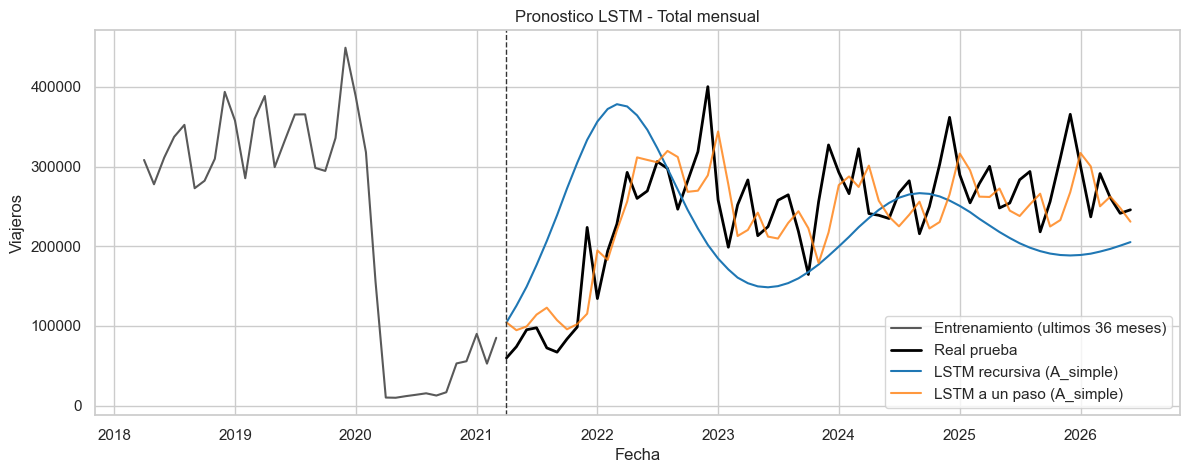

In [11]:
mejor_familia_prueba = tabla_modelos_finales.iloc[0]["familia"]
pred_mejor = modelos_finales[mejor_familia_prueba]["predicciones"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_train.tail(36).index, serie_train.tail(36).values, label="Entrenamiento (ultimos 36 meses)", color="0.35")
ax.plot(serie_prueba.index, serie_prueba.values, label="Real prueba", color="black", linewidth=2)
ax.plot(pred_mejor.index, pred_mejor["pred_recursiva"], label=f"LSTM recursiva ({mejor_familia_prueba})", color="#1f77b4")
ax.plot(pred_mejor.index, pred_mejor["pred_un_paso"], label=f"LSTM a un paso ({mejor_familia_prueba})", color="#ff7f0e", alpha=0.8)

ax.axvline(serie_prueba.index.min(), color="0.2", linestyle="--", linewidth=1)
ax.set_title(f"Pronostico LSTM - {config.SERIES_LAB1[SERIE]['etiqueta']}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Viajeros")
ax.legend()
plt.show()

## **Comparación preliminar contra el Laboratorio 1**

Esta tabla deja lista una primera comparación contra el mejor modelo del Laboratorio 1. La comparación importante es con el pronóstico recursivo de la LSTM, porque no usa valores reales del periodo de prueba.

Si la LSTM tiene menor MAE y RMSE, entonces mejora al modelo anterior. Si los errores son mayores, el modelo clásico sigue funcionando mejor para esta serie.


In [12]:
mejor_lstm = tabla_modelos_finales.iloc[0]
lab1 = config.MEJORES_LAB1[SERIE]

comparacion_lab1 = pd.DataFrame([
    {
        "modelo": f"LSTM {mejor_lstm['familia']}",
        "MAE": mejor_lstm["MAE_recursivo"],
        "RMSE": mejor_lstm["RMSE_recursivo"],
        "fuente": "Lab 2 - pronostico recursivo",
    },
    {
        "modelo": lab1["modelo"],
        "MAE": lab1["MAE"],
        "RMSE": lab1["RMSE"],
        "fuente": "Mejor modelo Lab 1",
    },
]).sort_values("RMSE").reset_index(drop=True)

comparacion_lab1

,modelo,MAE,RMSE,fuente
0,LSTM A_simple,77920.646364,95255.05054,Lab 2 - pronostico recursivo
1,Suav. exp. simple,158777.000000,173709.00000,Mejor modelo Lab 1
